## Libraries

In [5]:
import yfinance as yf

In [6]:
import pandas as pd
import numpy as np

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

## Data Collection

In [16]:
usd_inr = yf.download('USDINR=X', start = '2025-01-01', end='2026-05-31',interval='1wk')

[*********************100%***********************]  1 of 1 completed


In [17]:
type(usd_inr)

pandas.DataFrame

In [18]:
usd_inr.head()

Price,Close,High,Low,Open,Volume
Ticker,USDINR=X,USDINR=X,USDINR=X,USDINR=X,USDINR=X
Date,,,,,
2025-01-01,85.680702,86.072304,84.939598,85.785698,0
2025-01-08,86.650597,86.855301,85.706001,85.806503,0
2025-01-15,86.211098,86.669197,86.064796,86.535400,0
2025-01-22,86.468399,86.593002,86.150002,86.451897,0
2025-01-29,86.943398,87.325600,86.487999,86.584602,0


In [19]:
usd_inr.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 74 entries, 2025-01-01 to 2026-05-27
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, USDINR=X)   74 non-null     float64
 1   (High, USDINR=X)    74 non-null     float64
 2   (Low, USDINR=X)     74 non-null     float64
 3   (Open, USDINR=X)    74 non-null     float64
 4   (Volume, USDINR=X)  74 non-null     int64  
dtypes: float64(4), int64(1)
memory usage: 3.5 KB


In [21]:
usd_inr.shape

(74, 5)

In [22]:
usd_inr.reset_index(inplace = True)
usd_inr.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,USDINR=X,USDINR=X,USDINR=X,USDINR=X,USDINR=X
0,2025-01-01,85.680702,86.072304,84.939598,85.785698,0
1,2025-01-08,86.650597,86.855301,85.706001,85.806503,0
2,2025-01-15,86.211098,86.669197,86.064796,86.535400,0
3,2025-01-22,86.468399,86.593002,86.150002,86.451897,0
4,2025-01-29,86.943398,87.325600,86.487999,86.584602,0


In [23]:
usd_inr.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,USDINR=X,USDINR=X,USDINR=X,USDINR=X,USDINR=X
0,2025-01-01,85.680702,86.072304,84.939598,85.785698,0
1,2025-01-08,86.650597,86.855301,85.706001,85.806503,0
2,2025-01-15,86.211098,86.669197,86.064796,86.535400,0
3,2025-01-22,86.468399,86.593002,86.150002,86.451897,0
4,2025-01-29,86.943398,87.325600,86.487999,86.584602,0


In [24]:
usd_inr = usd_inr[['Date','Close']]

In [25]:
usd_inr.columns = ['Date','USD_INR']

In [26]:
usd_inr.head()

,Date,USD_INR
0,2025-01-01,85.680702
1,2025-01-08,86.650597
2,2025-01-15,86.211098
3,2025-01-22,86.468399
4,2025-01-29,86.943398


In [27]:
gold_price = pd.read_csv('price.csv')
gold_price.head()

,Date,Goldrate
0,2025-01-01,7219.42
1,2025-01-08,7354.60
2,2025-01-15,7492.43
3,2025-01-22,7660.36
4,2025-01-29,7689.02


In [28]:
usd_inr['Date'] = pd.to_datetime(usd_inr['Date'])
gold_price['Date'] = pd.to_datetime(gold_price['Date'])

gold_pred = pd.merge(
    usd_inr,
    gold_price,
    on='Date',
    how='inner'
)

In [29]:
gold_pred.head()

,Date,USD_INR,Goldrate
0,2025-01-01,85.680702,7219.42
1,2025-01-08,86.650597,7354.60
2,2025-01-15,86.211098,7492.43
3,2025-01-22,86.468399,7660.36
4,2025-01-29,86.943398,7689.02


 ## Data Analysis

In [30]:
gold_pred.head()

,Date,USD_INR,Goldrate
0,2025-01-01,85.680702,7219.42
1,2025-01-08,86.650597,7354.60
2,2025-01-15,86.211098,7492.43
3,2025-01-22,86.468399,7660.36
4,2025-01-29,86.943398,7689.02


## EDA (Exploratory Data Analysis)

* Handling Missing values
* Handle imbalanced Dataset
* Handle outliers
* Encode Categorical futures
* Normalization vs stadardisation

In [31]:
gold_pred.isnull().sum()

Date        0
USD_INR     0
Goldrate    0
dtype: int64

#### No Imbalanced dataset

<Axes: ylabel='USD_INR'>

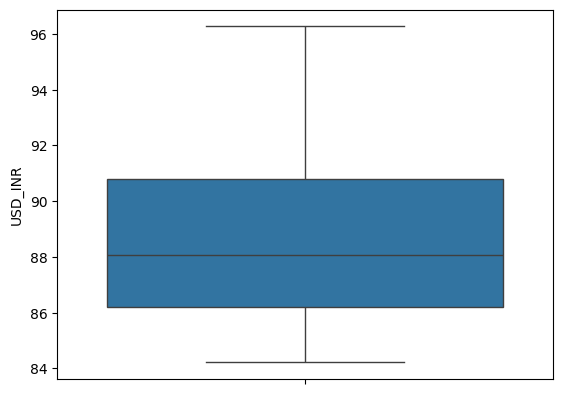

In [32]:
sns.boxplot(gold_pred['USD_INR'] )

#### We don;t have an Categorical Data 

In [33]:
gold_pred.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype        
---  ------    --------------  -----        
 0   Date      74 non-null     datetime64[s]
 1   USD_INR   74 non-null     float64      
 2   Goldrate  74 non-null     float64      
dtypes: datetime64[s](1), float64(2)
memory usage: 1.9 KB


In [34]:
gold_pred['Goldrate'].head(10)

0    7219.42
1    7354.60
2    7492.43
3    7660.36
4    7689.02
5    8055.77
6    8115.76
7    8197.42
8    8178.75
9    8145.31
Name: Goldrate, dtype: float64

<Axes: xlabel='USD_INR', ylabel='Goldrate'>

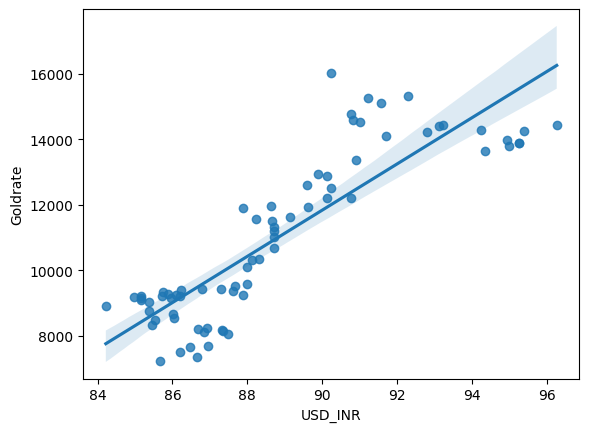

In [35]:
sns.regplot(x= 'USD_INR',y ='Goldrate',data = gold_pred)

## ML Model

In [36]:
x = gold_pred[['USD_INR']]
y = gold_pred[['Goldrate']]

In [37]:
type(x)

pandas.DataFrame

In [38]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size = 0.1,random_state=42)

In [39]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((66, 1), (8, 1), (66, 1), (8, 1))

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
X_test_scaled

array([[-0.64398044],
       [ 1.45404972],
       [-1.30256374],
       [-1.06446401],
       [-0.8931014 ],
       [ 2.0399051 ],
       [-0.65297171],
       [-0.2916593 ]])

In [42]:
from sklearn.linear_model import LinearRegression 
model = LinearRegression()
model.fit(X_train_scaled,y_train)

LinearRegression()

In [43]:
model.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [44]:
model.coef_

array([[2119.70571721]])

In [45]:
model.intercept_

array([11133.47666667])

In [46]:
# y = mx + b
m = model.coef_[0][0]
b = model.intercept_[0]

In [47]:
print(m,b)

2119.7057172082136 11133.476666666667


In [48]:
x_train_predict = model.predict(X_train_scaled)

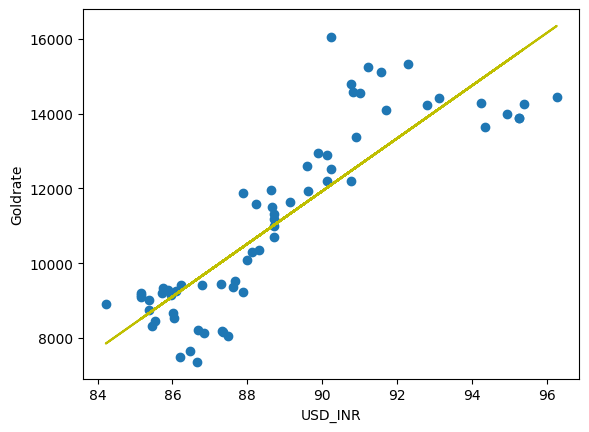

In [49]:
plt.scatter(X_train,y_train)
plt.plot(X_train,x_train_predict, color = 'y')
plt.xlabel('USD_INR')
plt.ylabel('Goldrate')

plt.show()

In [50]:
x_test_predicted = model.predict(X_test_scaled)
x_test_predicted

array([[ 9768.42764333],
       [14215.63418065],
       [ 8372.42486078],
       [ 8877.12622669],
       [ 9240.36451248],
       [15457.47516438],
       [ 9749.36879452],
       [10515.24478342]])

In [51]:
y_test

,Goldrate
4,7689.02
63,14450.00
18,9177.32
0,7219.42
28,9196.82
73,13788.00
10,8227.37
34,9572.63


## Hyperparameter Optimization

In [52]:
from sklearn.model_selection import RandomizedSearchCV
param_space = {
    'copy_X':[True,False],
    'fit_intercept':[True,False],
    'n_jobs':[1,5,10,15,None],
    'positive':[True,False]
}

In [53]:
search = RandomizedSearchCV(
    model,
    param_space,
    n_iter=40,
    cv=5,
    random_state=42
)

In [54]:
search.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=LinearRegression(), n_iter=40,
                   param_distributions={'copy_X': [True, False],
                                        'fit_intercept': [True, False],
                                        'n_jobs': [1, 5, 10, 15, None],
                                        'positive': [True, False]},
                   random_state=42)

In [55]:
search.best_params_

{'positive': True, 'n_jobs': 1, 'fit_intercept': True, 'copy_X': True}

In [56]:
tuned_model = LinearRegression(positive=True,n_jobs=1,fit_intercept=True,copy_X=True)

In [57]:
tuned_model.fit(X_train_scaled,y_train)

LinearRegression(n_jobs=1, positive=True)

In [58]:
tuned_model.coef_

array([[2119.70571721]])

# Machine Learning Operations (MLOPS)

* ### Save the Model
* ### Build Interface
* ### Connect Model & Interface

In [59]:
import pickle

In [60]:
pickle.dump(model, open('Gold.pkl','wb'  ))

In [61]:
model_reloaded = pickle.load(open('Gold.pkl','rb'))

In [62]:
model_reloaded.coef_

array([[2119.70571721]])

In [63]:
pickle.dump(scaler,open('scaler.pkl','wb'))

In [ ]:
import gradio as gr

def calculate_gold_rate(usd_inr):
    scaled_input = scaler.transform(np.array(usd_inr).reshape(1,-1))
    return model.predict(scaled_input)[0][0].round(2)

demo = gr.Interface(
    fn=calculate_gold_rate,
    inputs=['number'],
    outputs=['number'],
    title="How Much is 1g Gold Now in INR",  
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


c:\Users\MANIKANDAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\MANIKANDAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


15991.82


c:\Users\MANIKANDAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
